In [35]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, multilabel_confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

### Loading and Splitting Dataset

In [36]:
iris = load_iris()

[Sepal Length: 5.1, Sepal Width: 3.5, Petal Length: 1.4, Petal Width: 0.2]


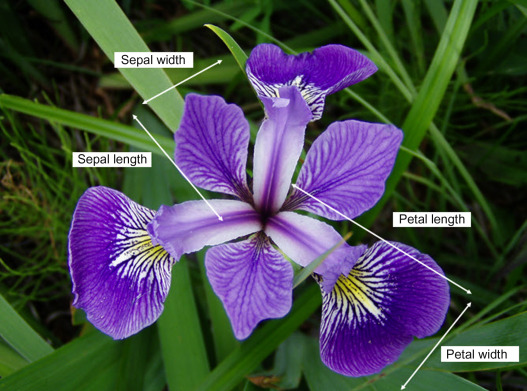

In [37]:
from IPython.display import Image
Image(filename='sepal.jpg') 
print(f"[Sepal Length: {iris.data[0, 0]}, Sepal Width: {iris.data[0, 1]}, Petal Length: {iris.data[0, 2]}, Petal Width: {iris.data[0, 3]}]")
Image(filename='sepal.jpg')

In [38]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
#['setosa', 'versicolor', 'virginica']
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [39]:
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size = 0.2, stratify=iris.target)

## Decision Tree

### Training

In [54]:
decision_tree = DecisionTreeClassifier(max_depth = 2)
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2)

[Text(372.0, 755.0, 'petal width (cm) <= 0.8\ngini = 0.667\nsamples = 120\nvalue = [40, 40, 40]\nclass = setosa'),
 Text(186.0, 453.0, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]\nclass = setosa'),
 Text(558.0, 453.0, 'petal length (cm) <= 4.85\ngini = 0.5\nsamples = 80\nvalue = [0, 40, 40]\nclass = versicolor'),
 Text(372.0, 151.0, 'gini = 0.05\nsamples = 39\nvalue = [0, 38, 1]\nclass = versicolor'),
 Text(744.0, 151.0, 'gini = 0.093\nsamples = 41\nvalue = [0, 2, 39]\nclass = virginica')]

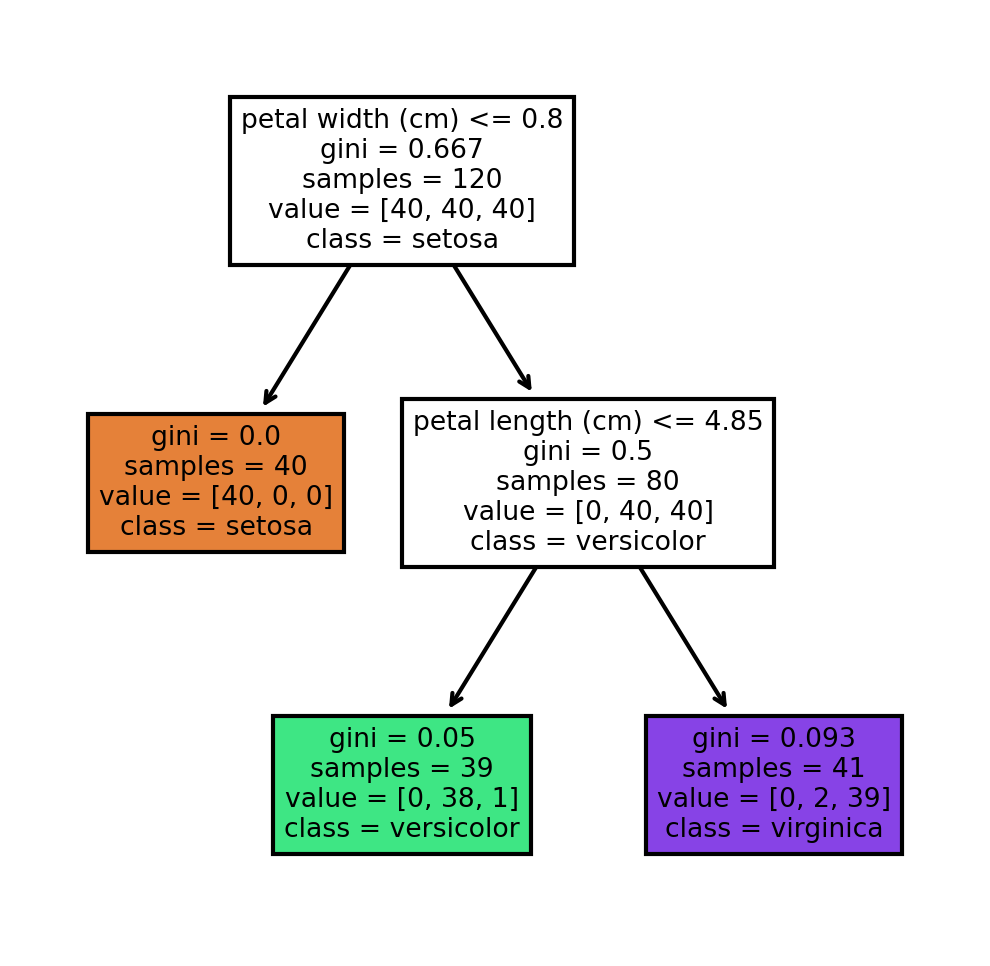

In [55]:
fn=['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']
cn=['setosa', 'versicolor', 'virginica']
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=300)
tree.plot_tree(decision_tree,
               feature_names = fn, 
               class_names=cn,
               filled = True)

### Testing/Evaluation

In [42]:
predictions = decision_tree.predict(X_test)
print("Predictions: ", predictions)
print("Truth:       ", y_test)
print(accuracy_score(predictions, y_test))

Predictions:  [2 2 1 0 2 0 0 1 0 1 0 1 1 1 1 1 2 2 1 2 0 0 2 1 2 0 2 0 0 2]
Truth:        [2 1 1 0 2 0 0 2 0 1 0 1 1 1 1 2 2 2 1 1 0 0 2 1 2 0 2 0 0 2]
0.8666666666666667


AttributeError: 'AxesSubplot' object has no property 'x_axis'

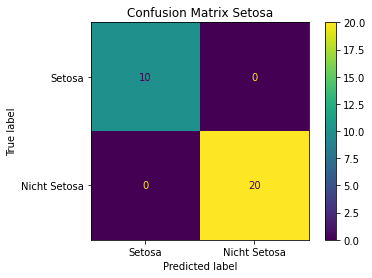

In [43]:
cm = multilabel_confusion_matrix(predictions, y_test)
disp = ConfusionMatrixDisplay(confusion_matrix=np.fliplr(np.flipud(cm[0])), display_labels=["Setosa", "Nicht Setosa"])
disp.plot()
disp.ax_.set(title='Confusion Matrix Setosa', x_axis="test")
plt.show()

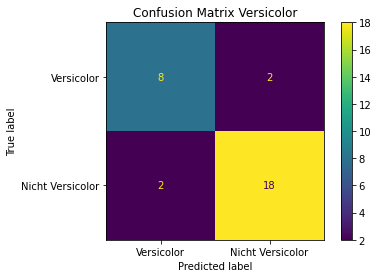

In [44]:
cm = multilabel_confusion_matrix(predictions, y_test)
disp = ConfusionMatrixDisplay(confusion_matrix=np.flipud(np.fliplr(cm[2])), display_labels=["Versicolor", "Nicht Versicolor"])
disp.plot()
disp.ax_.set(title='Confusion Matrix Versicolor')
plt.show()

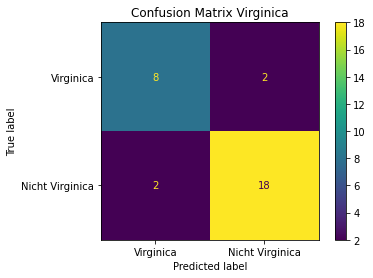

In [45]:
cm = multilabel_confusion_matrix(predictions, y_test)
disp = ConfusionMatrixDisplay(confusion_matrix=np.fliplr(np.flipud(cm[1])), display_labels=["Virginica", "Nicht Virginica"])
disp.plot()
disp.ax_.set(title='Confusion Matrix Virginica')
plt.show()

## Random Forest

### Training

In [46]:
random_forest = RandomForestClassifier(max_depth = 2, n_estimators = 10)
random_forest.fit(X_train, y_train)

RandomForestClassifier(max_depth=2, n_estimators=10)

[Text(465.0, 755.0, 'sepal length (cm) <= 5.55\ngini = 0.665\nsamples = 79\nvalue = [39, 44, 37]\nclass = versicolor'),
 Text(232.5, 453.0, 'petal length (cm) <= 2.6\ngini = 0.33\nsamples = 30\nvalue = [38, 10, 0]\nclass = setosa'),
 Text(116.25, 151.0, 'gini = 0.0\nsamples = 25\nvalue = [38, 0, 0]\nclass = setosa'),
 Text(348.75, 151.0, 'gini = 0.0\nsamples = 5\nvalue = [0, 10, 0]\nclass = versicolor'),
 Text(697.5, 453.0, 'petal width (cm) <= 1.7\ngini = 0.513\nsamples = 49\nvalue = [1, 34, 37]\nclass = virginica'),
 Text(581.25, 151.0, 'gini = 0.116\nsamples = 23\nvalue = [1, 31, 1]\nclass = versicolor'),
 Text(813.75, 151.0, 'gini = 0.142\nsamples = 26\nvalue = [0, 3, 36]\nclass = virginica')]

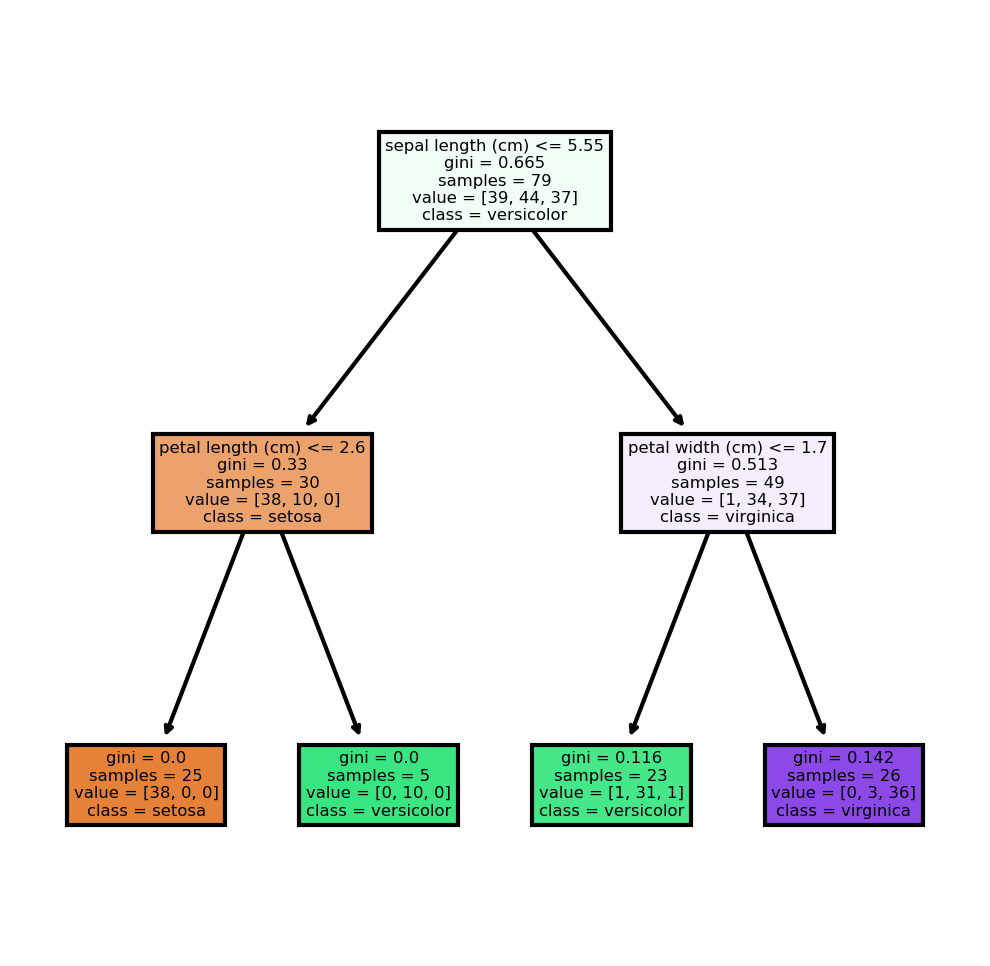

In [47]:
tree_nr = 1
fn=['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']
cn=['setosa', 'versicolor', 'virginica']
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=300)
tree.plot_tree(random_forest.estimators_[tree_nr],
               feature_names = fn, 
               class_names=cn,
               filled = True)

In [48]:
predictions = random_forest.predict(X_test)
print(predictions)
print(y_test)
print(accuracy_score(predictions, y_test))
# confusion matrix pro blume

[2 1 1 0 2 0 0 2 0 1 0 1 1 1 1 1 2 2 1 1 0 0 2 1 2 0 1 0 0 2]
[2 1 1 0 2 0 0 2 0 1 0 1 1 1 1 2 2 2 1 1 0 0 2 1 2 0 2 0 0 2]
0.9333333333333333


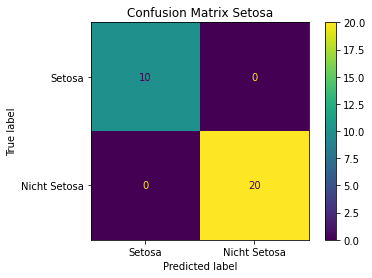

In [49]:
cm = multilabel_confusion_matrix(predictions, y_test)
disp = ConfusionMatrixDisplay(confusion_matrix=np.fliplr(np.flipud(cm[0])), display_labels=["Setosa", "Nicht Setosa"])
disp.plot()
disp.ax_.set(title='Confusion Matrix Setosa')
plt.show()

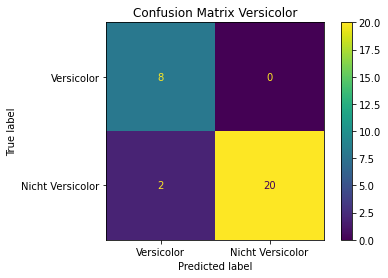

In [50]:
cm = multilabel_confusion_matrix(predictions, y_test)
disp = ConfusionMatrixDisplay(confusion_matrix=np.fliplr(np.flipud(cm[2])), display_labels=["Versicolor", "Nicht Versicolor"])
disp.plot()
disp.ax_.set(title='Confusion Matrix Versicolor')
plt.show()

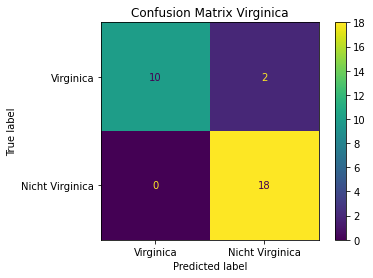

In [51]:
cm = multilabel_confusion_matrix(predictions, y_test)
disp = ConfusionMatrixDisplay(confusion_matrix=np.fliplr(np.flipud(cm[1])), display_labels=["Virginica", "Nicht Virginica"])
disp.plot()
disp.ax_.set(title='Confusion Matrix Virginica')
plt.show()